# First-order loss

$$\frac{d[A]}{dt} = -k[A], \qquad [A] = [A]_0 e^{-kt}$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

`solve_ivp` needs three things:

1. **The right-hand side**, a function `f(t, y)` returning `dy/dt`. This has to be `y` and is always a 1-D array, one entry per species. So `A = y[0]`, and the function returns a list or array of the same length.
2. **The time span** `(t0, t_end)` as a tuple. The solver picks its own internal steps; it does not take a step size from you.
3. **The initial condition** `y0`, an array the same length as `y`.

Optional but useful:

- `t_eval`: the times you want output at. Without it you get whatever internal steps the solver happened to take.
- `method`: `'RK45'` (default) is fine here. Use `'BDF'` or `'LSODA'` when rate constants differ by orders of magnitude (stiff chemistry).
- `rtol`, relative tolerance, and `atol` absolute tolerances, which default `1e-3` and `1e-6`. 

The result `sol` has `sol.t` (times) and `sol.y` (shape `n_species x n_times`), so `sol.y[0]` is the first species.

In [2]:
k = 0.5     # s-1
A0 = 1.0
t_end = 10.0

def rhs(t, y):
    A = y[0]            # unpack the state vector
    return [-k * A]     # return dy/dt, same length as y

sol = solve_ivp(rhs,                            # 1. dy/dt = f(t, y)
                (0.0, t_end),                   # 2. integrate from t=0 to t_end
                [A0],                           # 3. y at t=0
                t_eval=np.linspace(0, t_end, 200),   # where to report the solution
                rtol=1e-8, atol=1e-10)          # tolerances

t, A = sol.t, sol.y[0]

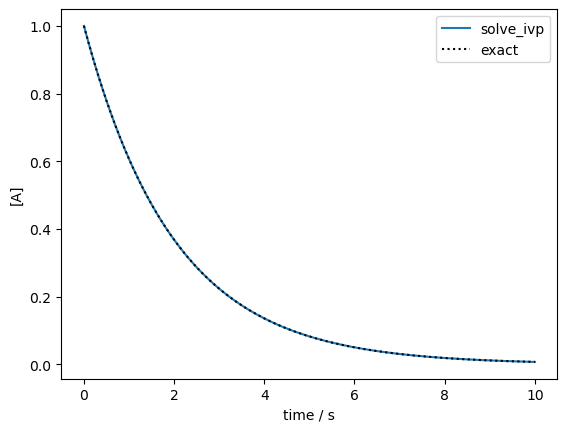

In [3]:
plt.plot(t, A, label="solve_ivp")
plt.plot(t, A0 * np.exp(-k * t), "k:", label="exact")
plt.xlabel("time / s")
plt.ylabel("[A]")
plt.legend();